# Load and display housing.csv

Very basic: this notebook only loads `housing.csv` from the repository root and displays the dataframe's shape and first few rows.

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv("housing.csv", delim_whitespace=True, header=None)
X = df.iloc[:, :-1].to_numpy(dtype=float)
y = df.iloc[:, -1].to_numpy(dtype=float)
#normalization
m, n = X.shape  
mu = X.mean(axis=0)
sigma = X.std(axis=0, ddof=0)
#checking if std deviation is equal to 0, if it is make it 1
sigma[sigma == 0] = 1.0  
X = (X - mu) / sigma

In [2]:
# Partition into train/val/test (80/10/10)
rng = np.random.default_rng(42)
perm = rng.permutation(m)

m_train = int(0.80 * m)
m_val = int(0.10 * m)
m_test = m - m_train - m_val

idx_train = perm[:m_train]
idx_val = perm[m_train:m_train+m_val]
idx_test = perm[m_train+m_val:]

X_train, y_train = X[idx_train], y[idx_train]
X_val, y_val = X[idx_val], y[idx_val]
X_test, y_test = X[idx_test], y[idx_test]

print(f"Train: {m_train}, Val: {m_val}, Test: {m_test}")


Train: 404, Val: 50, Test: 52


In [3]:
# Original training and evaluation code (unchanged)
#creating a weights vector and b
w = np.zeros(n, dtype=float)
b = 0.0

#linear regression function f(x) = w.x+b
def f(X, w, b):
    return X @ w + b

#gradient descent
def step(X, y, w, b, alpha):
    m = len(y)
    e = f(X, w, b) - y
    grad_w = (X.T @ e) / m
    grad_b = e.mean()
    return w - alpha * grad_w, b - alpha * grad_b

#cost function
def cost(X, y, w, b):
    e = f(X, w, b) - y
    return 0.5 * np.mean(e ** 2)

alpha = 0.05      
max_epochs = 5000 
tol = 1e-8        
prev_J = None

for epoch in range(1, max_epochs + 1):
    w, b = step(X, y, w, b, alpha)
    J = cost(X, y, w, b)
    if prev_J is not None and abs(prev_J - J) < tol:
        break  
    prev_J = J


y_pred = f(X, w, b)

mse = np.mean((y - y_pred) ** 2)


print(f"final_cost J(w,b): {J:.6f}")
print(f"MSE: {mse:.6f}")
print("bias b:", round(b, 6))
print("weights w:", np.round(w, 6))


final_cost J(w,b): 10.947417
MSE: 21.894834
bias b: 22.532806
weights w: [-0.927823  1.081001  0.139138  0.681992 -2.056412  2.67455   0.019195
 -3.104173  2.657771 -2.071726 -2.060442  0.849237 -3.743456]


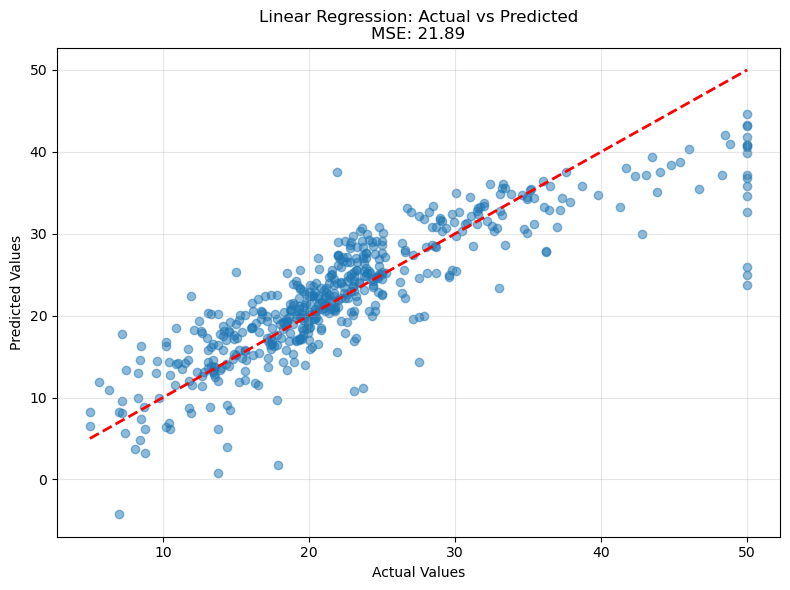


Visualization complete!


In [4]:
import matplotlib.pyplot as plt

# Visualization
plt.figure(figsize=(8, 6))

# Actual vs Predicted
plt.scatter(y, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Linear Regression: Actual vs Predicted\nMSE: {mse:.2f}')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('linear_regression_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization complete!")
